## Experiment No: 9
## Experiment Title: Text Summarization using Transformer Models

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Setup and Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

TRANSFORMERS_AVAILABLE = True
try:
    from transformers import pipeline
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("[WARNING] 'transformers' (and/or 'torch') is not installed.")
    print("          Install with: pip install transformers torch")

ROUGE_AVAILABLE = True
try:
    from rouge_score import rouge_scorer
except ImportError:
    ROUGE_AVAILABLE = False
    print("[WARNING] 'rouge_score' is not installed.")
    print("          Install with: pip install rouge_score")

In [2]:
# Download the sentence-tokenizer resource only if it is missing
for resource in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

### Step 2: Input Article and Reference Summary

In [3]:
article = """
Artificial intelligence is transforming the way businesses operate across the world.
Companies are increasingly using machine learning models to automate repetitive tasks
and improve decision making. Natural language processing, a branch of AI, allows
computers to understand and generate human language. This has led to major advances
in chatbots, translation systems, and text summarization tools. However, experts warn
that AI systems can also introduce bias if the training data is not carefully selected.
Researchers are working on techniques to make AI models more fair and transparent.
Governments around the world are also starting to introduce regulations to ensure AI
is used responsibly. Despite the challenges, AI adoption continues to grow rapidly
across industries such as healthcare, finance, and education. Many experts believe
that the next decade will see even faster progress in AI capabilities.
"""
article = " ".join(article.split())

reference_summary = ("AI is transforming businesses through automation and NLP advances, "
                      "but bias and regulation remain challenges as adoption grows across industries.")

print(f"Article word count: {len(article.split())}")
print(f"\nReference Summary:\n{reference_summary}")

Article word count: 134

Reference Summary:
AI is transforming businesses through automation and NLP advances, but bias and regulation remain challenges as adoption grows across industries.


### Step 3: Preprocessing — Sentence Tokenization

In [4]:
sentences = sent_tokenize(article)
print(f"Number of sentences: {len(sentences)}")

Number of sentences: 9


### Step 4: Extractive Summarization (TF-IDF Sentence Scoring)

In [5]:
NUM_EXTRACTIVE_SENTENCES = 3

vectorizer   = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(sentences)

sentence_scores = np.asarray(tfidf_matrix.sum(axis=1)).ravel()

top_indices        = sorted(np.argsort(sentence_scores)[-NUM_EXTRACTIVE_SENTENCES:])
extractive_summary = " ".join(sentences[i] for i in top_indices)

sentence_df = pd.DataFrame({
    "Sentence_ID": range(len(sentences)),
    "Sentence": [s if len(s) <= 70 else s[:67] + "..." for s in sentences],
    "TFIDF_Score": np.round(sentence_scores, 4),
    "Selected_for_Summary": [i in top_indices for i in range(len(sentences))]
})
sentence_df

,Sentence_ID,Sentence,TFIDF_Score,Selected_for_Summary
0,0,Artificial intelligence is transforming the wa...,2.6417,False
1,1,Companies are increasingly using machine learn...,3.4608,True
2,2,"Natural language processing, a branch of AI, a...",3.0032,False
3,3,"This has led to major advances in chatbots, tr...",2.9963,False
4,4,"However, experts warn that AI systems can also...",3.1219,True
5,5,Researchers are working on techniques to make ...,2.7868,False
6,6,Governments around the world are also starting...,2.9589,False
7,7,"Despite the challenges, AI adoption continues ...",3.2826,True
8,8,Many experts believe that the next decade will...,2.6018,False


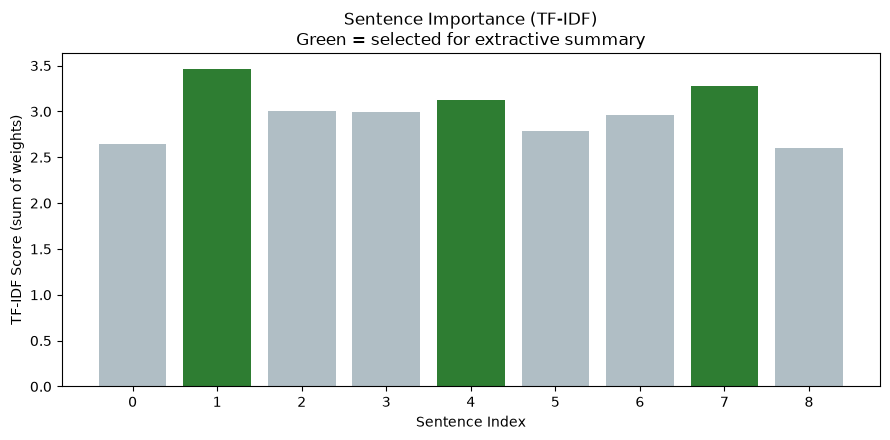

Extractive Summary:
Companies are increasingly using machine learning models to automate repetitive tasks and improve decision making. However, experts warn that AI systems can also introduce bias if the training data is not carefully selected. Despite the challenges, AI adoption continues to grow rapidly across industries such as healthcare, finance, and education.


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2E7D32" if sel else "#B0BEC5" for sel in sentence_df["Selected_for_Summary"]]
ax.bar(sentence_df["Sentence_ID"], sentence_df["TFIDF_Score"], color=colors)
ax.set_xlabel("Sentence Index")
ax.set_ylabel("TF-IDF Score (sum of weights)")
ax.set_title("Sentence Importance (TF-IDF)\nGreen = selected for extractive summary")
ax.set_xticks(sentence_df["Sentence_ID"])
plt.tight_layout()
plt.show()

print("Extractive Summary:")
print(extractive_summary)

### Step 5: Abstractive Summarization (Pretrained Transformer — DistilBART)


In [7]:
abstractive_summary = None
model_load_error = None

if TRANSFORMERS_AVAILABLE:
    try:
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

        MODEL_NAME = "sshleifer/distilbart-cnn-12-6"
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

        inputs = tokenizer(article, return_tensors="pt", truncation=True)
        summary_ids = model.generate(
            **inputs,
            max_length=60,
            min_length=20,
            num_beams=4,
            do_sample=False,
            forced_bos_token_id=0,
        )
        abstractive_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        print("Abstractive Summary:")
        print(abstractive_summary)
    except Exception as e:
        model_load_error = str(e)
        print("[ERROR] Could not load/run the Transformer model.")
        print(f"        Reason: {model_load_error}")
        print("        This step requires 'transformers' + 'torch' and internet access")
        print("        to download model weights on first use.")
else:
    print("[SKIPPED] 'transformers' is not installed — abstractive summarization was not run.")
    print("          Install with: pip install transformers torch")

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Abstractive Summary:
 Companies are increasingly using machine learning models to automate repetitive tasks . Natural language processing, a branch of AI, allows computers to understand and generate human language . This has led to major advances in chatbots, translation systems and text summarization tools .


### Step 6: Compare Reference, Extractive, and Abstractive Summaries

In [8]:
summary_comparison_df = pd.DataFrame({
    "Type": ["Reference", "Extractive", "Abstractive"],
    "Summary": [
        reference_summary,
        extractive_summary,
        abstractive_summary if abstractive_summary else "(not generated — see Step 5)"
    ]
})
pd.set_option("display.max_colwidth", None)
summary_comparison_df

,Type,Summary
0,Reference,"AI is transforming businesses through automation and NLP advances, but bias and regulation remain challenges as adoption grows across industries."
1,Extractive,"Companies are increasingly using machine learning models to automate repetitive tasks and improve decision making. However, experts warn that AI systems can also introduce bias if the training data is not carefully selected. Despite the challenges, AI adoption continues to grow rapidly across industries such as healthcare, finance, and education."
2,Abstractive,"Companies are increasingly using machine learning models to automate repetitive tasks . Natural language processing, a branch of AI, allows computers to understand and generate human language . This has led to major advances in chatbots, translation systems and text summarization tools ."


In [9]:
word_counts = {
    "Original Article": len(article.split()),
    "Extractive Summary": len(extractive_summary.split()),
}
if abstractive_summary:
    word_counts["Abstractive Summary"] = len(abstractive_summary.split())

compression_df = pd.DataFrame({
    "Text": list(word_counts.keys()),
    "Word_Count": list(word_counts.values())
})
compression_df["Compression_%"] = np.round(
    100 * (1 - compression_df["Word_Count"] / word_counts["Original Article"]), 1
)
compression_df

,Text,Word_Count,Compression_%
0,Original Article,134,0.0
1,Extractive Summary,50,62.7
2,Abstractive Summary,43,67.9


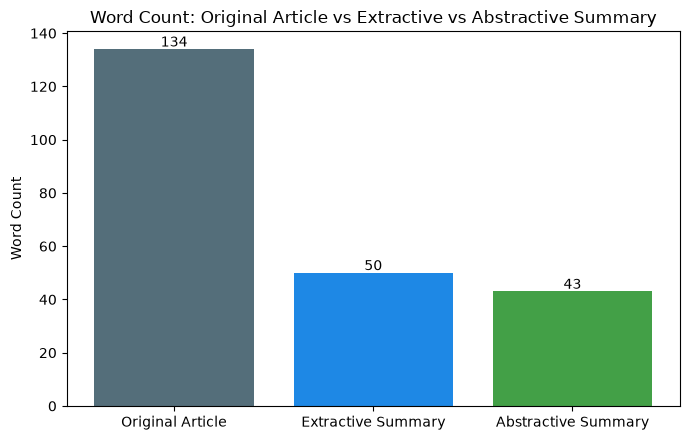

In [10]:
bar_colors = ["#546E7A", "#1E88E5", "#43A047"][:len(compression_df)]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(compression_df["Text"], compression_df["Word_Count"], color=bar_colors)
ax.set_ylabel("Word Count")
ax.set_title("Word Count: Original Article vs Extractive vs Abstractive Summary")
for i, v in enumerate(compression_df["Word_Count"]):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

### Step 7: ROUGE Evaluation of Summaries

In [11]:
extractive_scores = None
abstractive_scores = None

if ROUGE_AVAILABLE:
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    extractive_scores = scorer.score(reference_summary, extractive_summary)
    if abstractive_summary:
        abstractive_scores = scorer.score(reference_summary, abstractive_summary)
    else:
        print("[SKIPPED] Abstractive ROUGE scores not computed — no abstractive summary was generated.")
else:
    print("[SKIPPED] 'rouge_score' is not installed — ROUGE scores were not computed.")
    print("          Install with: pip install rouge_score")

### Step 8: Results Table — ROUGE F1 Comparison

In [12]:
rows = []
for metric, label in [("rouge1", "ROUGE-1"), ("rouge2", "ROUGE-2"), ("rougeL", "ROUGE-L")]:
    rows.append({
        "Metric": label,
        "Extractive F1": round(extractive_scores[metric].fmeasure, 3) if extractive_scores else np.nan,
        "Abstractive F1": round(abstractive_scores[metric].fmeasure, 3) if abstractive_scores else np.nan,
    })
rouge_table = pd.DataFrame(rows)
rouge_table

,Metric,Extractive F1,Abstractive F1
0,ROUGE-1,0.343,0.167
1,ROUGE-2,0.029,0.000
2,ROUGE-L,0.229,0.133


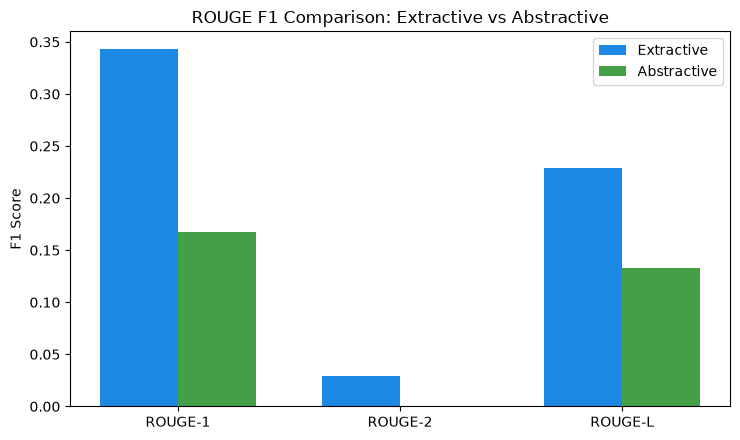

In [13]:
if extractive_scores:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x = np.arange(len(rouge_table))
    width = 0.35
    ax.bar(x - width / 2, rouge_table["Extractive F1"], width, label="Extractive", color="#1E88E5")
    if abstractive_scores:
        ax.bar(x + width / 2, rouge_table["Abstractive F1"], width, label="Abstractive", color="#43A047")
    ax.set_xticks(x)
    ax.set_xticklabels(rouge_table["Metric"])
    ax.set_ylabel("F1 Score")
    ax.set_title("ROUGE F1 Comparison: Extractive vs Abstractive")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[SKIPPED] No ROUGE scores available to plot.")